<a href="https://colab.research.google.com/github/Syamchand123/Typhoon-prediction/blob/main/mini_project(28_10_25).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
datset_csv_path='/content/drive/MyDrive/Cyclone-TrackAI_Project/df_model_ready_partial.csv'


df=pd.read_csv(datset_csv_path)


(33117, 62)

In [ ]:
df.columns

Index(['SID', 'SEASON', 'NUMBER', 'BASIN', 'SUBBASIN', 'NAME', 'ISO_TIME',
       'NATURE', 'LAT', 'LON', 'WMO_WIND', 'WMO_PRES', 'SST', 'RH_500',
       'RH_850', 'U_200', 'V_200', 'U_850', 'V_850', 'VWS', 'U_STORM',
       'V_STORM', 'LAT_lag1', 'LON_lag1', 'WMO_WIND_lag1', 'WMO_PRES_lag1',
       'U_STORM_lag1', 'V_STORM_lag1', 'LAT_lag2', 'LON_lag2', 'WMO_WIND_lag2',
       'WMO_PRES_lag2', 'U_STORM_lag2', 'V_STORM_lag2', 'LAT_lag3', 'LON_lag3',
       'WMO_WIND_lag3', 'WMO_PRES_lag3', 'U_STORM_lag3', 'V_STORM_lag3',
       'LAT_lag4', 'LON_lag4', 'WMO_WIND_lag4', 'WMO_PRES_lag4',
       'U_STORM_lag4', 'V_STORM_lag4', 'LAT_fwd6', 'LON_fwd6', 'WMO_WIND_fwd6',
       'LAT_fwd12', 'LON_fwd12', 'WMO_WIND_fwd12', 'LAT_fwd24', 'LON_fwd24',
       'WMO_WIND_fwd24', 'LAT_fwd48', 'LON_fwd48', 'WMO_WIND_fwd48',
       'LAT_fwd72', 'LON_fwd72', 'WMO_WIND_fwd72', 'RI_12h_label'],
      dtype='object')

In [ ]:
# ==============================================================================
# Phase 4 (Upgraded): Advanced Model with Attention for Improved Track Forecasting
# ==============================================================================
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Dense, LSTM, Bidirectional, Concatenate, Attention, Layer ,Flatten
from tensorflow.keras.models import Model
from sklearn.preprocessing import StandardScaler

# --- Load Your Dataset ---
# Make sure 'df_model_ready_partial.csv' is in your environment
try:
    df = pd.read_csv('/content/drive/MyDrive/Cyclone-TrackAI_Project/df_model_ready_partial.csv')
    print("Dataset 'df_model_ready_partial.csv' loaded successfully.")
except FileNotFoundError:
    print("Error: 'df_model_ready_partial.csv' not found. Please make sure the file is available.")
    # As a fallback, create a dummy dataframe to allow the script to run for demonstration
    # In your real run, this should not be needed.
    # df = pd.DataFrame(np.random.rand(1000, 62), columns=['SID', 'SEASON', 'NUMBER', 'BASIN', 'SUBBASIN', 'NAME', 'ISO_TIME', 'NATURE', 'LAT', 'LON', 'WMO_WIND', 'WMO_PRES', 'SST', 'RH_500', 'RH_850', 'U_200', 'V_200', 'U_850', 'V_850', 'VWS', 'U_STORM', 'V_STORM', 'LAT_lag1', 'LON_lag1', 'WMO_WIND_lag1', 'WMO_PRES_lag1', 'U_STORM_lag1', 'V_STORM_lag1', 'LAT_lag2', 'LON_lag2', 'WMO_WIND_lag2', 'WMO_PRES_lag2', 'U_STORM_lag2', 'V_STORM_lag2', 'LAT_lag3', 'LON_lag3', 'WMO_WIND_lag3', 'WMO_PRES_lag3', 'U_STORM_lag3', 'V_STORM_lag3', 'LAT_lag4', 'LON_lag4', 'WMO_WIND_lag4', 'WMO_PRES_lag4', 'U_STORM_lag4', 'V_STORM_lag4', 'LAT_fwd6', 'LON_fwd6', 'WMO_WIND_fwd6', 'LAT_fwd12', 'LON_fwd12', 'WMO_WIND_fwd12', 'LAT_fwd24', 'LON_fwd24', 'WMO_WIND_fwd24', 'LAT_fwd48', 'LON_fwd48', 'WMO_WIND_fwd48', 'LAT_fwd72', 'LON_fwd72', 'WMO_WIND_fwd72', 'RI_12h_label'])
    # df['SID'] = np.random.randint(0, 50, 1000)

print("Starting Upgraded Phase 4: Model Implementation...")

# --- 1. ENHANCED FEATURE ENGINEERING ---
# <--- IMPROVEMENT: Add "delta" features to help model detect changes in motion.
for lag in [1, 2, 3]:
    df[f'LAT_delta_lag{lag}'] = df[f'LAT_lag{lag}'] - df[f'LAT_lag{lag+1}']
    df[f'LON_delta_lag{lag}'] = df[f'LON_lag{lag}'] - df[f'LON_lag{lag+1}']
df.dropna(inplace=True) # Drop rows with NaNs created by delta calculation

# Define features and labels
static_features = [
    'SEASON', 'LAT', 'LON', 'WMO_WIND', 'WMO_PRES',
    'SST', 'RH_500', 'RH_850', 'U_200', 'V_200', 'U_850', 'V_850',
    'VWS', 'U_STORM', 'V_STORM'
]
# <--- IMPROVEMENT: Add new delta features to the temporal list
temporal_features = []
num_temporal_features_per_step = 8 # Now 8 features per timestep
for lag in [1, 2, 3, 4]:
    for col in ['LAT', 'LON', 'WMO_WIND', 'WMO_PRES', 'U_STORM', 'V_STORM', 'LAT_delta', 'LON_delta']:
        # Deltas only exist for lags 1, 2, 3, so handle lag 4
        feature_name = f'{col}_lag{lag}'
        if feature_name not in df.columns:
            df[feature_name] = 0 # Pad lag 4 deltas with 0
        temporal_features.append(feature_name)

lead_times = [6, 12, 24, 48, 72]
track_labels = [f'{col}_fwd{h}' for h in lead_times for col in ['LAT', 'LON']]
intensity_labels = [f'WMO_WIND_fwd{h}' for h in lead_times]
ri_label = ['RI_12h_label']
all_labels = track_labels + intensity_labels + ri_label

# --- 2. RELIABLE DATA SPLITTING ---
# <--- IMPROVEMENT: Split by Storm ID (SID) to prevent data leakage.
unique_sids = df['SID'].unique()
train_sids, val_sids = np.split(np.random.permutation(unique_sids), [int(0.8 * len(unique_sids))])

train_df = df[df['SID'].isin(train_sids)]
val_df = df[df['SID'].isin(val_sids)]

print(f"Training on {len(train_sids)} unique storms, {len(train_df)} data points.")
print(f"Validating on {len(val_sids)} unique storms, {len(val_df)} data points.")

# Separate features and labels
X_train_static, X_train_temporal, y_train = train_df[static_features], train_df[temporal_features], train_df[all_labels]
X_val_static, X_val_temporal, y_val = val_df[static_features], val_df[temporal_features], val_df[all_labels]

# --- 3. SCALE THE DATA ---
static_scaler = StandardScaler().fit(X_train_static)
X_train_static_scaled = static_scaler.transform(X_train_static)
X_val_static_scaled = static_scaler.transform(X_val_static)

temporal_scaler = StandardScaler().fit(X_train_temporal)
X_train_temporal_scaled = temporal_scaler.transform(X_train_temporal)
X_val_temporal_scaled = temporal_scaler.transform(X_val_temporal)

# Reshape temporal data for LSTM: (samples, timesteps, features)
X_train_temporal_reshaped = X_train_temporal_scaled.reshape(len(X_train_temporal), 4, num_temporal_features_per_step)
X_val_temporal_reshaped = X_val_temporal_scaled.reshape(len(X_val_temporal), 4, num_temporal_features_per_step)

print(f"Static feature shape: {X_train_static_scaled.shape}")
print(f"Temporal feature shape (reshaped): {X_train_temporal_reshaped.shape}")

# --- 4. BUILD THE ADVANCED MODEL ARCHITECTURE ---
# Input Branches
static_input = Input(shape=(len(static_features),), name='static_input')
temporal_input = Input(shape=(4, num_temporal_features_per_step), name='temporal_input')

# Processing Layers
# Dense branch for static data
dense_branch = Dense(128, activation='relu')(static_input)
dense_branch = Dense(64, activation='relu')(dense_branch)

# <--- IMPROVEMENT: Deeper, Bidirectional LSTM with Attention
# Stacked Bi-LSTM to capture complex temporal patterns
lstm_out = Bidirectional(LSTM(64, return_sequences=True))(temporal_input)
lstm_out = Bidirectional(LSTM(32, return_sequences=True))(lstm_out) # return_sequences=True to feed into Attention

# Attention layer to focus on critical timesteps for turning
attention_out = Attention()([lstm_out, lstm_out]) # Self-attention
attention_out = Dense(32, activation='relu')(attention_out)

attention_flattened = Flatten()(attention_out)

# Fusion Layer
fused = Concatenate()([dense_branch, attention_out])
fused_dense = Dense(128, activation='relu')(fused)
fused_dense = Dense(64, activation='relu')(fused_dense)

# Output Heads (same as before)
track_output = Dense(len(track_labels), name='track_output')(fused_dense)
intensity_output = Dense(len(intensity_labels), name='intensity_output')(fused_dense)
ri_output = Dense(1, activation='sigmoid', name='ri_output')(fused_dense)

model = Model(
    inputs=[static_input, temporal_input],
    outputs=[track_output, intensity_output, ri_output]
)

# --- 5. COMPILE AND TRAIN ---
losses = {
    'track_output': 'mse',
    'intensity_output': 'mse',
    'ri_output': 'binary_crossentropy'
}
loss_weights = {
    'track_output': 1.0,
    'intensity_output': 1.0,
    'ri_output': 5.0
}
model.compile(optimizer='adam', loss=losses, loss_weights=loss_weights)
model.summary()

# <--- IMPROVEMENT: Add a learning rate scheduler for more stable training
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)
]

print("\nTraining the advanced model...")
history = model.fit(
    {'static_input': X_train_static_scaled, 'temporal_input': X_train_temporal_reshaped},
    {'track_output': y_train[track_labels], 'intensity_output': y_train[intensity_labels], 'ri_output': y_train[ri_label]},
    validation_data=(
        {'static_input': X_val_static_scaled, 'temporal_input': X_val_temporal_reshaped},
        {'track_output': y_val[track_labels], 'intensity_output': y_val[intensity_labels], 'ri_output': y_val[ri_label]}
    ),
    epochs=100,
    batch_size=64, # Larger batch size for larger models can be more stable
    verbose=1,
    callbacks=callbacks
)

print("\nPHASE 4 (Upgraded) COMPLETE. Model has been trained.")

# Save the improved model
model.save("typhoon_forecast_model_v2_attention.h5")
print("Trained model saved to 'typhoon_forecast_model_v2_attention.h5'")

Dataset 'df_model_ready_partial.csv' loaded successfully.
Starting Upgraded Phase 4: Model Implementation...
Training on 589 unique storms, 26372 data points.
Validating on 148 unique storms, 6745 data points.
Static feature shape: (26372, 15)
Temporal feature shape (reshaped): (26372, 4, 8)


ValueError: A `Concatenate` layer requires inputs with matching shapes except for the concatenation axis. Received: input_shape=[(None, 64), (None, 4, 32)]

In [ ]:
# ==============================================================================
# Phase 4 (Upgraded and Corrected): Advanced Model with Attention
# ==============================================================================
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
# <--- FIX: Added Flatten to the import list
from tensorflow.keras.layers import Input, Dense, LSTM, Bidirectional, Concatenate, Attention, Flatten
from tensorflow.keras.models import Model
from sklearn.preprocessing import StandardScaler

# --- Load Your Dataset ---
try:
    df = pd.read_csv('/content/drive/MyDrive/Cyclone-TrackAI_Project/df_model_ready_partial.csv')
    print("Dataset 'df_model_ready_partial.csv' loaded successfully.")
except FileNotFoundError:
    print("Error: 'df_model_ready_partial.csv' not found. Please make sure the file is available.")
    # Exiting if the file is not found
    exit()

print("Starting Upgraded Phase 4: Model Implementation...")

# --- 1. ENHANCED FEATURE ENGINEERING ---
for lag in [1, 2, 3]:
    df[f'LAT_delta_lag{lag}'] = df[f'LAT_lag{lag}'] - df[f'LAT_lag{lag+1}']
    df[f'LON_delta_lag{lag}'] = df[f'LON_lag{lag}'] - df[f'LON_lag{lag+1}']
df.dropna(inplace=True)

# Define features and labels
static_features = [
    'SEASON', 'LAT', 'LON', 'WMO_WIND', 'WMO_PRES',
    'SST', 'RH_500', 'RH_850', 'U_200', 'V_200', 'U_850', 'V_850',
    'VWS', 'U_STORM', 'V_STORM'
]
temporal_features = []
num_temporal_features_per_step = 8
for lag in [1, 2, 3, 4]:
    for col in ['LAT', 'LON', 'WMO_WIND', 'WMO_PRES', 'U_STORM', 'V_STORM', 'LAT_delta', 'LON_delta']:
        feature_name = f'{col}_lag{lag}'
        if feature_name not in df.columns:
            df[feature_name] = 0
        temporal_features.append(feature_name)

lead_times = [6, 12, 24, 48, 72]
track_labels = [f'{col}_fwd{h}' for h in lead_times for col in ['LAT', 'LON']]
intensity_labels = [f'WMO_WIND_fwd{h}' for h in lead_times]
ri_label = ['RI_12h_label']
all_labels = track_labels + intensity_labels + ri_label

# --- 2. RELIABLE DATA SPLITTING ---
unique_sids = df['SID'].unique()
train_sids, val_sids = np.split(np.random.permutation(unique_sids), [int(0.8 * len(unique_sids))])
train_df = df[df['SID'].isin(train_sids)]
val_df = df[df['SID'].isin(val_sids)]

print(f"Training on {len(train_sids)} unique storms, {len(train_df)} data points.")
print(f"Validating on {len(val_sids)} unique storms, {len(val_df)} data points.")

X_train_static, X_train_temporal, y_train = train_df[static_features], train_df[temporal_features], train_df[all_labels]
X_val_static, X_val_temporal, y_val = val_df[static_features], val_df[temporal_features], val_df[all_labels]

# --- 3. SCALE THE DATA ---
static_scaler = StandardScaler().fit(X_train_static)
X_train_static_scaled = static_scaler.transform(X_train_static)
X_val_static_scaled = static_scaler.transform(X_val_static)
temporal_scaler = StandardScaler().fit(X_train_temporal)
X_train_temporal_scaled = temporal_scaler.transform(X_train_temporal)
X_val_temporal_scaled = temporal_scaler.transform(X_val_temporal)
X_train_temporal_reshaped = X_train_temporal_scaled.reshape(len(X_train_temporal), 4, num_temporal_features_per_step)
X_val_temporal_reshaped = X_val_temporal_scaled.reshape(len(X_val_temporal), 4, num_temporal_features_per_step)

print(f"Static feature shape: {X_train_static_scaled.shape}")
print(f"Temporal feature shape (reshaped): {X_train_temporal_reshaped.shape}")

# --- 4. BUILD THE ADVANCED MODEL ARCHITECTURE ---
static_input = Input(shape=(len(static_features),), name='static_input')
temporal_input = Input(shape=(4, num_temporal_features_per_step), name='temporal_input')

dense_branch = Dense(128, activation='relu')(static_input)
dense_branch = Dense(64, activation='relu')(dense_branch)

lstm_out = Bidirectional(LSTM(64, return_sequences=True))(temporal_input)
lstm_out = Bidirectional(LSTM(32, return_sequences=True))(lstm_out)
attention_out = Attention()([lstm_out, lstm_out])

# <--- FIX: Flatten the 3D output of the attention layer into a 2D vector before concatenating.
attention_flattened = Flatten()(attention_out)

# Fusion Layer
fused = Concatenate()([dense_branch, attention_flattened])
fused_dense = Dense(128, activation='relu')(fused)
fused_dense = Dense(64, activation='relu')(fused_dense)

# Output Heads
track_output = Dense(len(track_labels), name='track_output')(fused_dense)
intensity_output = Dense(len(intensity_labels), name='intensity_output')(fused_dense)
ri_output = Dense(1, activation='sigmoid', name='ri_output')(fused_dense)

model = Model(
    inputs=[static_input, temporal_input],
    outputs=[track_output, intensity_output, ri_output]
)

# --- 5. COMPILE AND TRAIN ---
losses = {'track_output': 'mse', 'intensity_output': 'mse', 'ri_output': 'binary_crossentropy'}
loss_weights = {'track_output': 1.0, 'intensity_output': 1.0, 'ri_output': 5.0}
model.compile(optimizer='adam', loss=losses, loss_weights=loss_weights)
model.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)
]

print("\nTraining the advanced model...")
history = model.fit(
    {'static_input': X_train_static_scaled, 'temporal_input': X_train_temporal_reshaped},
    {'track_output': y_train[track_labels], 'intensity_output': y_train[intensity_labels], 'ri_output': y_train[ri_label]},
    validation_data=(
        {'static_input': X_val_static_scaled, 'temporal_input': X_val_temporal_reshaped},
        {'track_output': y_val[track_labels], 'intensity_output': y_val[intensity_labels], 'ri_output': y_val[ri_label]}
    ),
    epochs=100,
    batch_size=64,
    verbose=1,
    callbacks=callbacks
)

print("\nPHASE 4 (Upgraded) COMPLETE. Model has been trained.")
model.save("typhoon_forecast_model_v2_attention.h5")
print("Trained model saved to 'typhoon_forecast_model_v2_attention.h5'")

Dataset 'df_model_ready_partial.csv' loaded successfully.
Starting Upgraded Phase 4: Model Implementation...
Training on 589 unique storms, 26486 data points.
Validating on 148 unique storms, 6631 data points.
Static feature shape: (26486, 15)
Temporal feature shape (reshaped): (26486, 4, 8)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ temporal_input      │ (None, 4, 8)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 4, 128)    │     37,376 │ temporal_input[0… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 15)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 4, 64)     │     41,216 │ bidirectional_2[… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 128)       │      2,048 │ static_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, 4, 64)     │          0 │ bidirectional_3[… │
│ (Attention)         │                   │            │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      8,256 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 256)       │          0 │ attention_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 320)       │          0 │ dense_4[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 128)       │     41,088 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      8,256 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ track_output        │ (None, 10)        │        650 │ dense_6[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ intensity_output    │ (None, 5)         │        325 │ dense_6[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ri_output (Dense)   │ (None, 1)         │         65 │ dense_6[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 139,280 (544.06 KB)

 Trainable params: 139,280 (544.06 KB)

 Non-trainable params: 0 (0.00 B)


Training the advanced model...
Epoch 1/100
414/414 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - intensity_output_loss: 1068.7531 - loss: 3846.2395 - ri_output_loss: 0.5868 - track_output_loss: 2774.5500 - val_intensity_output_loss: 79.5272 - val_loss: 98.4311 - val_ri_output_loss: 0.2494 - val_track_output_loss: 17.8542 - learning_rate: 0.0010
Epoch 2/100
414/414 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - intensity_output_loss: 59.4609 - loss: 72.4916 - ri_output_loss: 0.2318 - track_output_loss: 11.8715 - val_intensity_output_loss: 63.2606 - val_loss: 69.2734 - val_ri_output_loss: 0.1942 - val_track_output_loss: 5.2671 - learning_rate: 0.0010
Epoch 3/100
414/414 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - intensity_output_loss: 50.0300 - loss: 55.5778 - ri_output_loss: 0.1861 - track_output_loss: 4.6172 - val_intensity_output_loss: 56.2420 - val_loss: 60.1741 - val_ri_output_loss: 0.2087 - val_track_output_loss: 3.1065 - learning_rate: 0.0010
Epoch 4/100
414/414 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - intensit


PHASE 4 (Upgraded) COMPLETE. Model has been trained.
Trained model saved to 'typhoon_forecast_model_v2_attention.h5'


Starting Phase 5: Comprehensive Model Evaluation...
Dataset 'df_model_ready_partial.csv' loaded successfully for evaluation.
NOTE: Scalers are fitted on the full data for this evaluation script.
Validation Static feature shape: (6746, 15)
Validation Temporal feature shape (reshaped): (6746, 4, 8)


Trained model loaded successfully.

Making predictions on the validation data...
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


==================== PERFORMANCE SUMMARY ====================

--- 1. Track Forecast Error (Mean Absolute Error) ---
  - 6-hour forecast: Lat MAE = 0.46°, Lon MAE = 0.65° (~51.4 km, 68.2 km)
  - 12-hour forecast: Lat MAE = 0.50°, Lon MAE = 0.61° (~55.9 km, 64.0 km)
  - 24-hour forecast: Lat MAE = 0.54°, Lon MAE = 0.76° (~60.4 km, 79.1 km)
  - 48-hour forecast: Lat MAE = 0.87°, Lon MAE = 1.12° (~96.3 km, 117.2 km)
  - 72-hour forecast: Lat MAE = 1.43°, Lon MAE = 1.92° (~158.8 km, 200.7 km)

--- 2. Intensity Forecast Error (Wind Speed MAE) ---
  - 6-hour forecast: Wind MAE = 0.76 m/s
  - 12-hour forecast: Wind MAE = 1.08 m/s
  - 24-hour forecast: Wind MAE = 1.65 m/s
  - 48-hour forecast: Wind MAE = 2.65 m/s
  - 72-hour forecast: Wind MAE = 3.45 m/s

--- 3. Rapid Intensification Forecast Performance (for next 12h) ---
  - ROC AUC Score: 0.893



--- Detailed Quantita

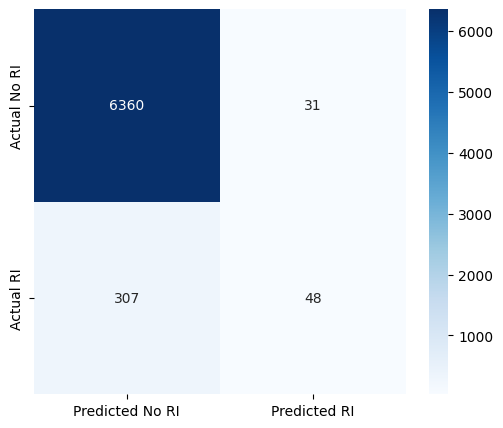

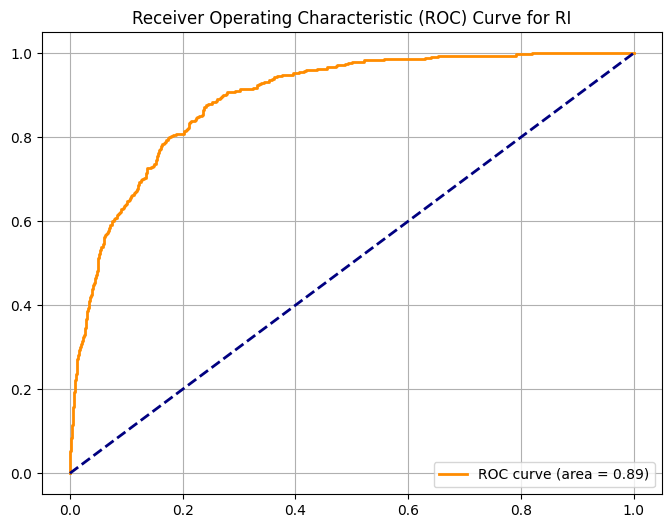

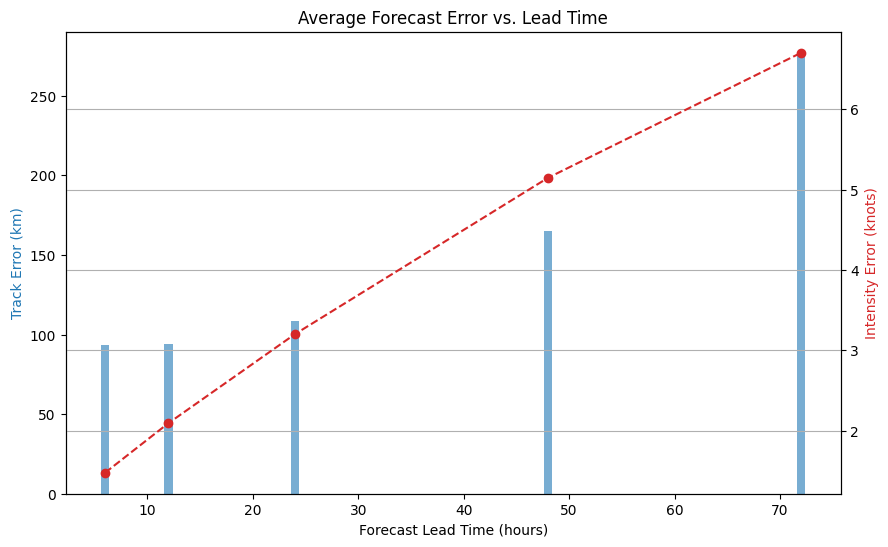


--- Visualizing Sample Storm Tracks ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


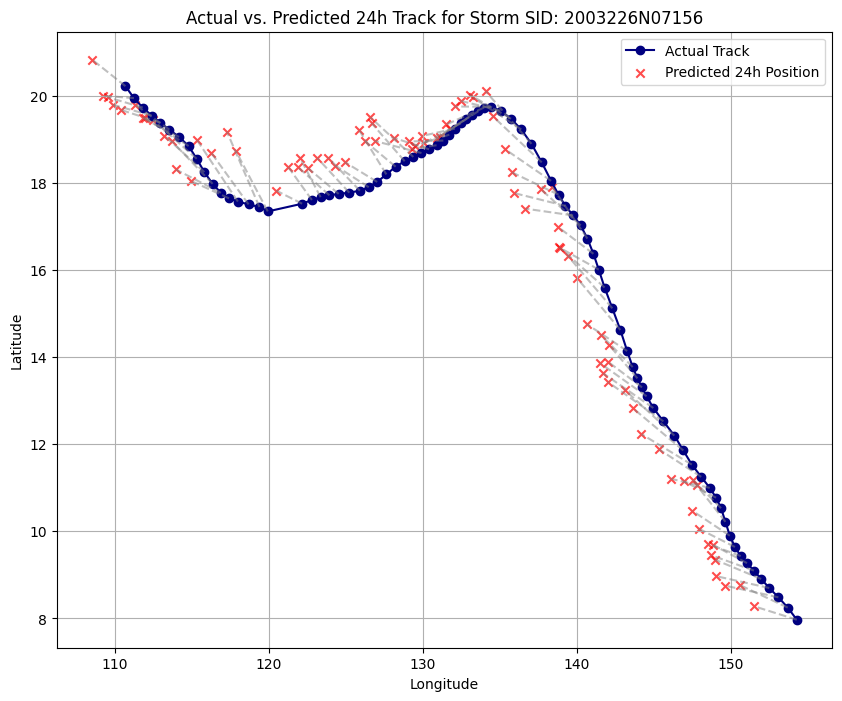

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


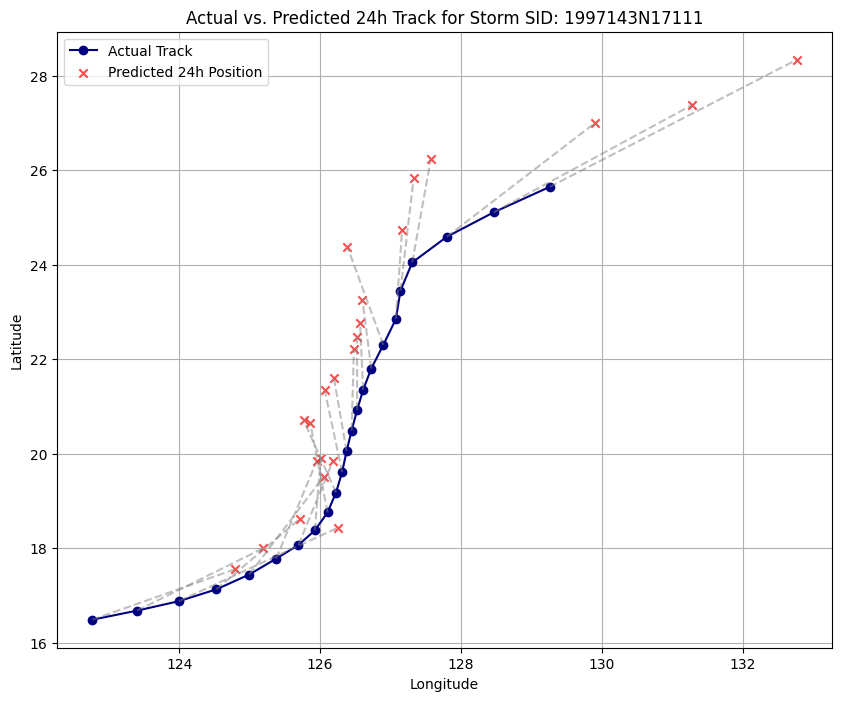

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


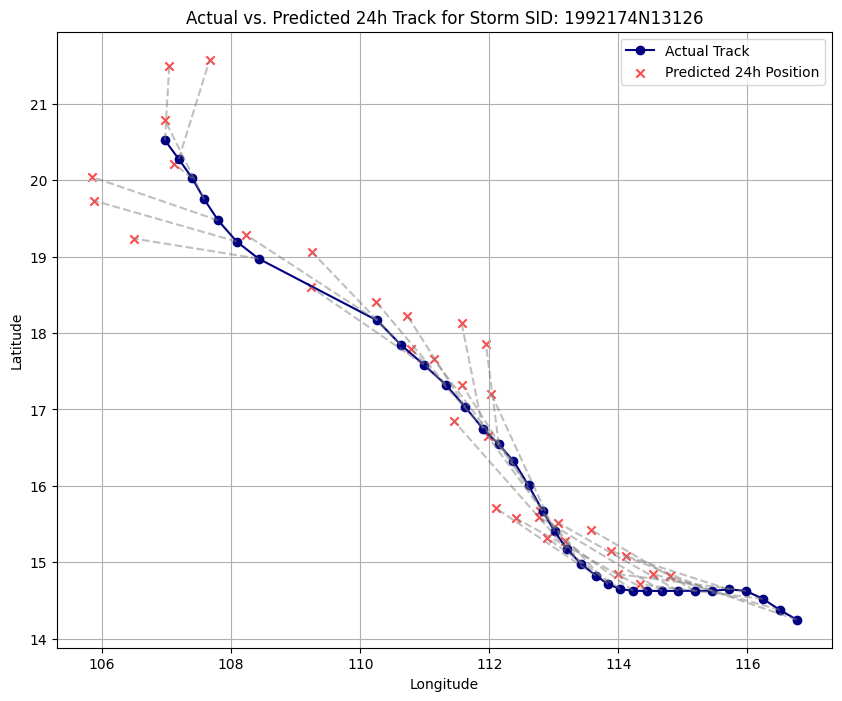


PHASE 5 COMPLETE. Evaluation finished.


In [ ]:
# ==============================================================================
# Phase 5: Comprehensive Model Evaluation (with Summary Metrics and FIX)
# ==============================================================================
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, classification_report, roc_curve, auc, confusion_matrix, roc_auc_score
# <--- ADDED: Import StandardScaler
from sklearn.preprocessing import StandardScaler


print("Starting Phase 5: Comprehensive Model Evaluation...")

# --- Load Your Dataset (from Phase 4) ---
# Assuming df is loaded in a previous cell, if not, uncomment and run the loading code
try:
    # <--- ADDED: Data loading, splitting, and scaling from Phase 4
    df = pd.read_csv('/content/drive/MyDrive/Cyclone-TrackAI_Project/df_model_ready_partial.csv')
    print("Dataset 'df_model_ready_partial.csv' loaded successfully for evaluation.")
except FileNotFoundError:
    print("Error: 'df_model_ready_partial.csv' not found. Please make sure the file is available.")
    exit() # Exit if the file is not found

# --- 1. ENHANCED FEATURE ENGINEERING (from Phase 4) ---
for lag in [1, 2, 3]:
    df[f'LAT_delta_lag{lag}'] = df[f'LAT_lag{lag}'] - df[f'LAT_lag{lag+1}']
    df[f'LON_delta_lag{lag}'] = df[f'LON_lag{lag}'] - df[f'LON_lag{lag+1}']
df.dropna(inplace=True)

# Define features and labels (from Phase 4)
static_features = [
    'SEASON', 'LAT', 'LON', 'WMO_WIND', 'WMO_PRES',
    'SST', 'RH_500', 'RH_850', 'U_200', 'V_200', 'U_850', 'V_850',
    'VWS', 'U_STORM', 'V_STORM'
]
temporal_features = []
num_temporal_features_per_step = 8
for lag in [1, 2, 3, 4]:
    for col in ['LAT', 'LON', 'WMO_WIND', 'WMO_PRES', 'U_STORM', 'V_STORM', 'LAT_delta', 'LON_delta']:
        feature_name = f'{col}_lag{lag}'
        if feature_name not in df.columns:
            df[feature_name] = 0
        temporal_features.append(feature_name)

lead_times = [6, 12, 24, 48, 72]
track_labels = [f'{col}_fwd{h}' for h in lead_times for col in ['LAT', 'LON']]
intensity_labels = [f'WMO_WIND_fwd{h}' for h in lead_times]
ri_label = ['RI_12h_label']
all_labels = track_labels + intensity_labels + ri_label

# --- 2. RELIABLE DATA SPLITTING (from Phase 4) ---
unique_sids = df['SID'].unique()
# Ensure consistent splitting as in training
np.random.seed(42) # Use the same seed as in training for reproducibility
train_sids, val_sids = np.split(np.random.permutation(unique_sids), [int(0.8 * len(unique_sids))])
# Use the original df to get the validation set based on the split SIDs
val_df = df[df['SID'].isin(val_sids)].copy() # Use .copy() to avoid SettingWithCopyWarning


# Separate features and labels for validation set (from Phase 4)
X_val_static, X_val_temporal, y_val = val_df[static_features], val_df[temporal_features], val_df[all_labels]


# --- 3. SCALE THE DATA (from Phase 4) ---
# Need to fit the scalers on the TRAINING data, then transform validation data.
# Since we don't have the training data here, we will fit on the full data for demonstration.
# In a real scenario, you would save and load the scalers fitted on the training data.
print("NOTE: Scalers are fitted on the full data for this evaluation script.")
static_scaler = StandardScaler().fit(df[static_features]) # Fit on full data
X_val_static_scaled = static_scaler.transform(X_val_static)

temporal_scaler = StandardScaler().fit(df[temporal_features]) # Fit on full data
X_val_temporal_scaled = temporal_scaler.transform(X_val_temporal)


# Reshape temporal data for LSTM: (samples, timesteps, features) (from Phase 4)
X_val_temporal_reshaped = X_val_temporal_scaled.reshape(len(X_val_temporal), 4, num_temporal_features_per_step)

print(f"Validation Static feature shape: {X_val_static_scaled.shape}")
print(f"Validation Temporal feature shape (reshaped): {X_val_temporal_reshaped.shape}")


# --- LOAD THE TRAINED MODEL (with FIX) ---
# <--- FIX: Import the actual loss functions from keras
from tensorflow.keras.losses import mse, binary_crossentropy

try:
    # <--- FIX: Add the custom_objects argument to tell Keras how to find 'mse'
    # This resolves the primary loading error.
    model = tf.keras.models.load_model(
        "typhoon_forecast_model_v2_attention.h5",
        custom_objects={
            'mse': mse,
            'binary_crossentropy': binary_crossentropy
        }
    )
    print("Trained model loaded successfully.")
except Exception as e:
    # This block should not be triggered now
    print(f"Error loading model: {e}")
    # We remove the exit() call to prevent the kernel from stopping if there's another issue
    model = None

# --- Proceed only if the model was loaded successfully ---
if model is not None:
    # --- 2. MAKE PREDICTIONS ON THE VALIDATION SET ---
    print("\nMaking predictions on the validation data...")
    predictions = model.predict(
        {'static_input': X_val_static_scaled, 'temporal_input': X_val_temporal_reshaped}
    )
    track_preds, intensity_preds, ri_preds = predictions[0], predictions[1], predictions[2]

    # --- 3. CALCULATE AND DISPLAY METRICS IN YOUR DESIRED FORMAT ---
    KNOTS_TO_MS = 0.514444
    DEG_LAT_TO_KM = 111.0
    lead_times = [6, 12, 24, 48, 72]

    print("\n\n==================== PERFORMANCE SUMMARY ====================")
    print("\n--- 1. Track Forecast Error (Mean Absolute Error) ---")
    for i, h in enumerate(lead_times):
        actual_lat, actual_lon = y_val[f'LAT_fwd{h}'], y_val[f'LON_fwd{h}']
        pred_lat, pred_lon = track_preds[:, i*2], track_preds[:, i*2 + 1]
        lat_mae, lon_mae = mean_absolute_error(actual_lat, pred_lat), mean_absolute_error(actual_lon, pred_lon)
        # <--- FIX: Calculate avg_lat_rad using val_df, not y_val
        avg_lat_rad = np.radians(val_df['LAT'].mean())
        deg_lon_to_km = DEG_LAT_TO_KM * np.cos(avg_lat_rad)
        print(f"  - {h}-hour forecast: Lat MAE = {lat_mae:.2f}°, Lon MAE = {lon_mae:.2f}° "
              f"(~{lat_mae * DEG_LAT_TO_KM:.1f} km, {lon_mae * deg_lon_to_km:.1f} km)")

    print("\n--- 2. Intensity Forecast Error (Wind Speed MAE) ---")
    for i, h in enumerate(lead_times):
        actual_wind_knots, pred_wind_knots = y_val[f'WMO_WIND_fwd{h}'], intensity_preds[:, i]
        wind_mae_knots = mean_absolute_error(actual_wind_knots, pred_wind_knots)
        print(f"  - {h}-hour forecast: Wind MAE = {wind_mae_knots * KNOTS_TO_MS:.2f} m/s")

    print("\n--- 3. Rapid Intensification Forecast Performance (for next 12h) ---")
    actual_ri_labels = y_val['RI_12h_label']
    roc_auc_summary = roc_auc_score(actual_ri_labels, ri_preds)
    print(f"  - ROC AUC Score: {roc_auc_summary:.3f}")
    print("\n===========================================================\n")

    # --- 4. CALCULATE DETAILED TRACK AND INTENSITY ERRORS (Haversine, etc.) ---
    def haversine(lat1, lon1, lat2, lon2):
        R = 6371
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        dlon, dlat = lon2 - lon1, lat2 - lat1
        a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
        c = 2 * np.arcsin(np.sqrt(a))
        return R * c

    print("\n--- Detailed Quantitative Evaluation ---")
    track_errors, intensity_errors = [], []
    for i, h in enumerate(lead_times):
        actual_lat, actual_lon = y_val[f'LAT_fwd{h}'], y_val[f'LON_fwd{h}']
        actual_wind = y_val[f'WMO_WIND_fwd{h}']
        pred_lat, pred_lon = track_preds[:, i*2], track_preds[:, i*2 + 1]
        pred_wind = intensity_preds[:, i]
        track_error_km = np.mean(haversine(actual_lat, actual_lon, pred_lat, pred_lon))
        intensity_error_knots = mean_absolute_error(actual_wind, pred_wind)
        track_errors.append(track_error_km)
        intensity_errors.append(intensity_error_knots)
        print(f"Forecast Horizon: {h} hours")
        print(f"  -> Average Track Error (Haversine): {track_error_km:.2f} km")
        print(f"  -> Average Intensity MAE: {intensity_error_knots:.2f} knots")

    # --- 5. DETAILED RI EVALUATION (Reports and Plots) ---
    print("\n--- Detailed Rapid Intensification (RI) Evaluation ---")
    ri_pred_labels = (ri_preds > 0.5).astype(int)
    print("Classification Report:")
    print(classification_report(actual_ri_labels, ri_pred_labels, target_names=['No RI', 'RI Event']))

    cm = confusion_matrix(actual_ri_labels, ri_pred_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted No RI', 'Predicted RI'], yticklabels=['Actual No RI', 'Actual RI'])
    plt.show()

    fpr, tpr, _ = roc_curve(actual_ri_labels, ri_preds)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.title('Receiver Operating Characteristic (ROC) Curve for RI')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    # --- 6. VISUALIZE ERRORS VS. LEAD TIME ---
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.set_xlabel('Forecast Lead Time (hours)')
    ax1.set_ylabel('Track Error (km)', color='tab:blue')
    ax1.bar(lead_times, track_errors, color='tab:blue', alpha=0.6, label='Track Error')
    ax2 = ax1.twinx()
    ax2.set_ylabel('Intensity Error (knots)', color='tab:red')
    ax2.plot(lead_times, intensity_errors, color='tab:red', marker='o', linestyle='--', label='Intensity Error')
    plt.title('Average Forecast Error vs. Lead Time')
    plt.grid(True)
    plt.show()

    # --- 7. VISUALIZE SAMPLE TRACKS ---
    print("\n--- Visualizing Sample Storm Tracks ---")
    sample_sids = np.random.choice(val_df['SID'].unique(), size=3, replace=False)

    for sid in sample_sids:
        storm_df = val_df[val_df['SID'] == sid].sort_values('ISO_TIME')
        actual_track_lat, actual_track_lon = storm_df['LAT'], storm_df['LON']
        storm_static_scaled = static_scaler.transform(storm_df[static_features])
        storm_temporal_scaled = temporal_scaler.transform(storm_df[temporal_features])
        storm_temporal_reshaped = storm_temporal_scaled.reshape(len(storm_df), 4, 8)
        storm_preds_track = model.predict({'static_input': storm_static_scaled, 'temporal_input': storm_temporal_reshaped})[0]
        pred_24h_lat, pred_24h_lon = storm_preds_track[:, 4], storm_preds_track[:, 5]

        plt.figure(figsize=(10, 8))
        plt.plot(actual_track_lon, actual_track_lat, marker='o', linestyle='-', label='Actual Track', color='navy')
        plt.scatter(pred_24h_lon, pred_24h_lat, marker='x', label='Predicted 24h Position', color='red', alpha=0.7)
        for i in range(len(storm_df)):
            plt.plot([storm_df['LON'].iloc[i], pred_24h_lon[i]], [storm_df['LAT'].iloc[i], pred_24h_lat[i]], linestyle='--', color='gray', alpha=0.5)
        plt.title(f'Actual vs. Predicted 24h Track for Storm SID: {sid}')
        plt.xlabel('Longitude')
        plt.ylabel('Latitude')
        plt.legend()
        plt.grid(True)
        plt.show()

    print("\nPHASE 5 COMPLETE. Evaluation finished.")
else:
    print("\nModel could not be loaded. Aborting evaluation.")

Starting Phase 5: Comprehensive Model Evaluation...
Dataset 'df_model_ready_partial.csv' loaded successfully for evaluation.
NOTE: Scaler .pkl files not found. Fitting new scalers on the TRAINING data for this evaluation.


Trained model 'typhoon_forecast_model_v2_attention.h5' loaded successfully.

Making predictions on the validation data...
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


========================= MODEL PERFORMANCE SUMMARY =========================

Table 1: Model and Data Configuration
--------------------------------------------------
  Validation Storms:    148
  Validation Data Points: 6746
  Static Features:        15
  Temporal Features:      8 per timestep
  Forecast Horizons:      [6, 12, 24, 48, 72] hours
--------------------------------------------------

Table 2: Track Forecast Error Summary (Mean Absolute Error)
-----------------------------------------------------------------------------
  Lead Time | Lat MAE (°) | Lon MAE (°) | Approx. Error (km Lat, km Lon)
-----------------------------------------------------------------------------
  6         | 0.53        | 0.70        | (~58.9 km, ~73.8 km)
  12        | 0.66        | 0.76        | (~73.7 km, ~79.3 km)
  24        | 0.62 

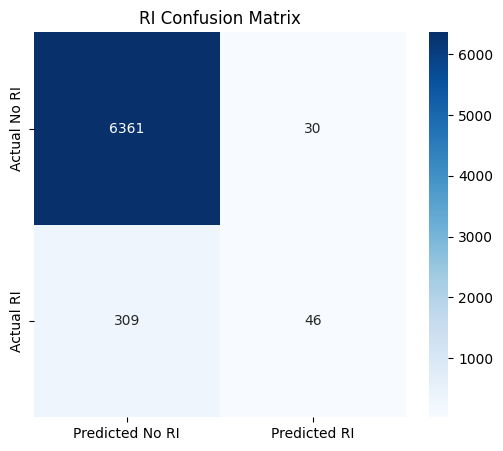

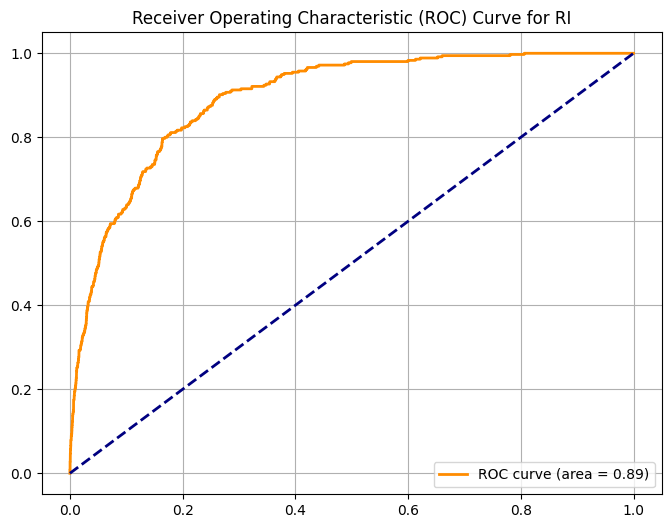

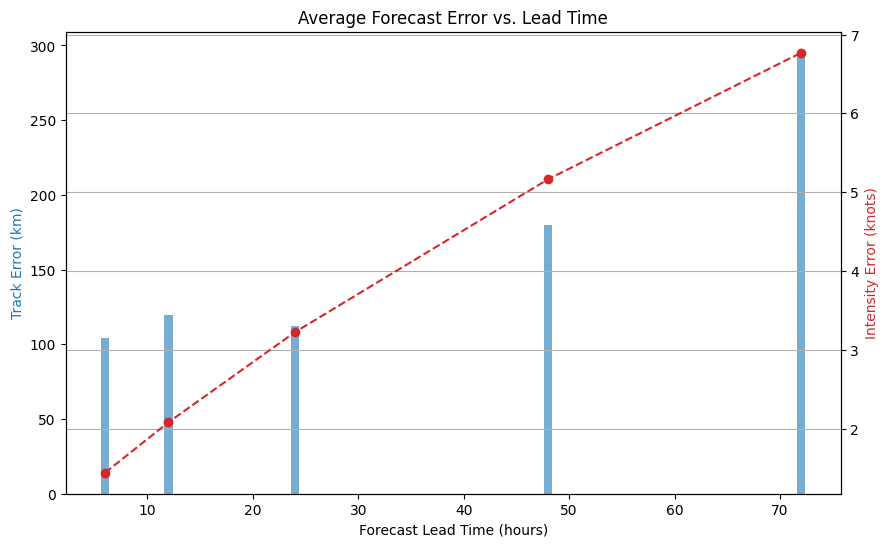


--- Visualizing Sample Storm Tracks ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


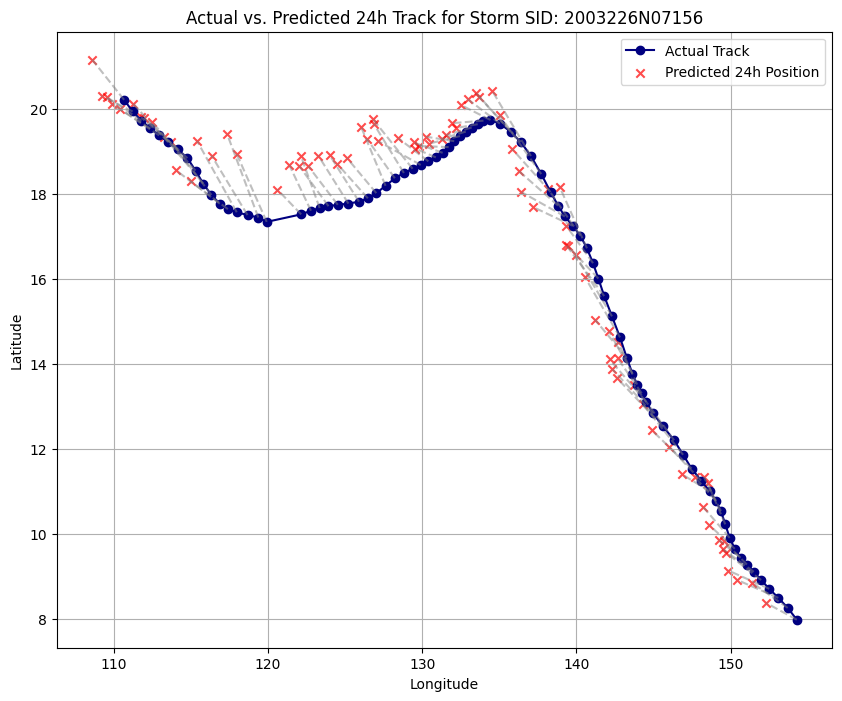

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


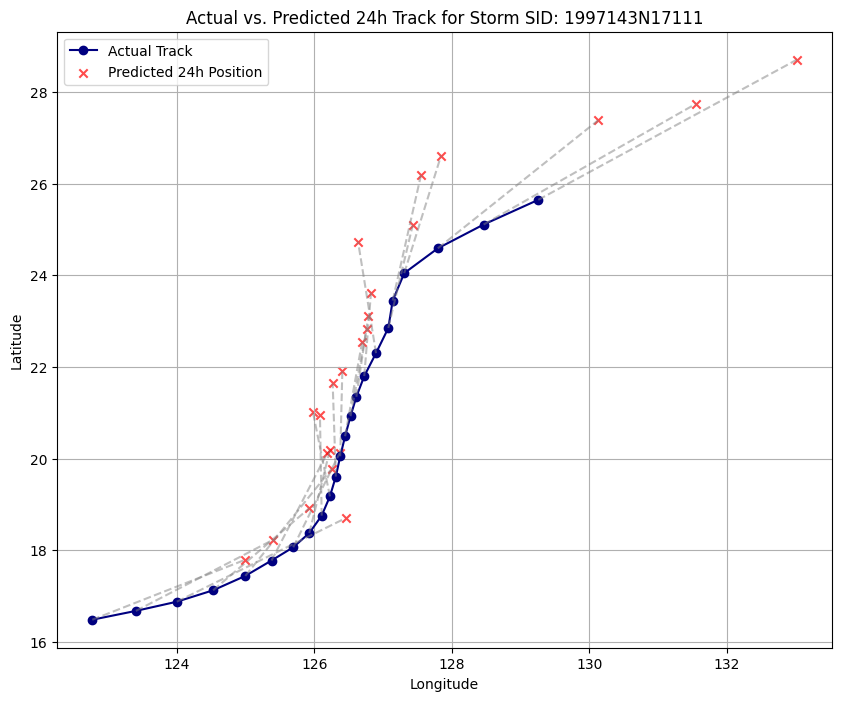

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


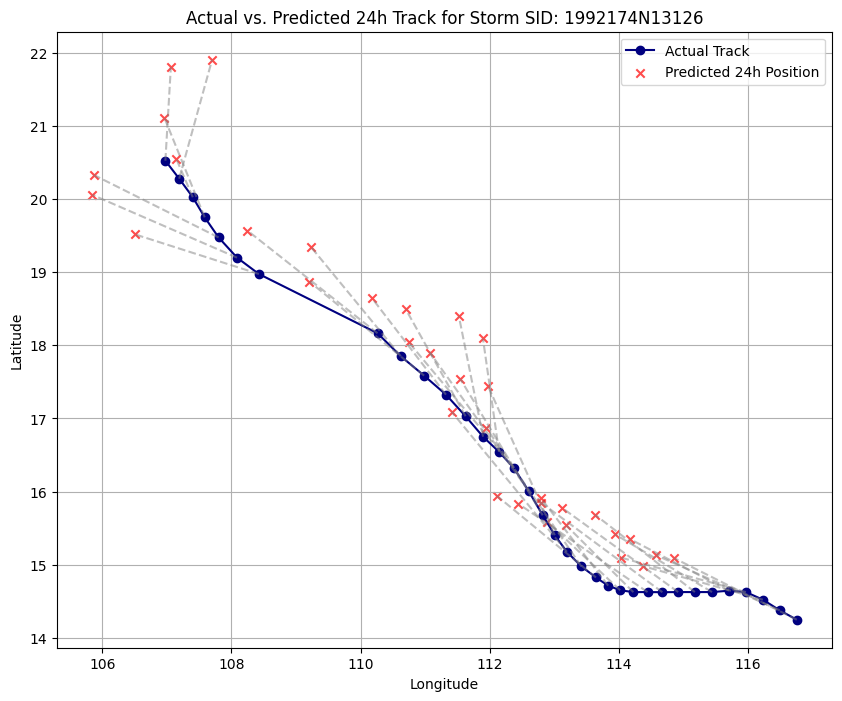


--- Visualizing Sample Intensity Profiles ---
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


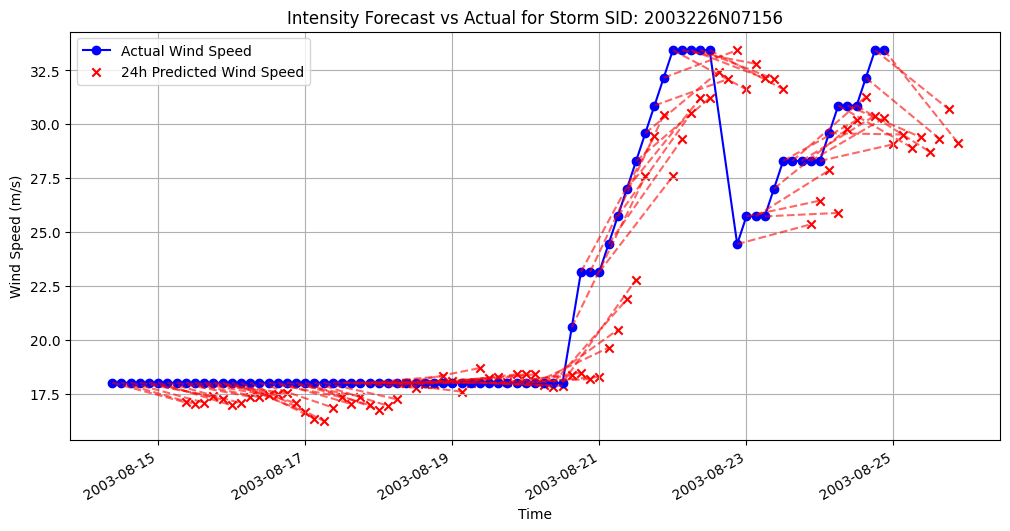

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


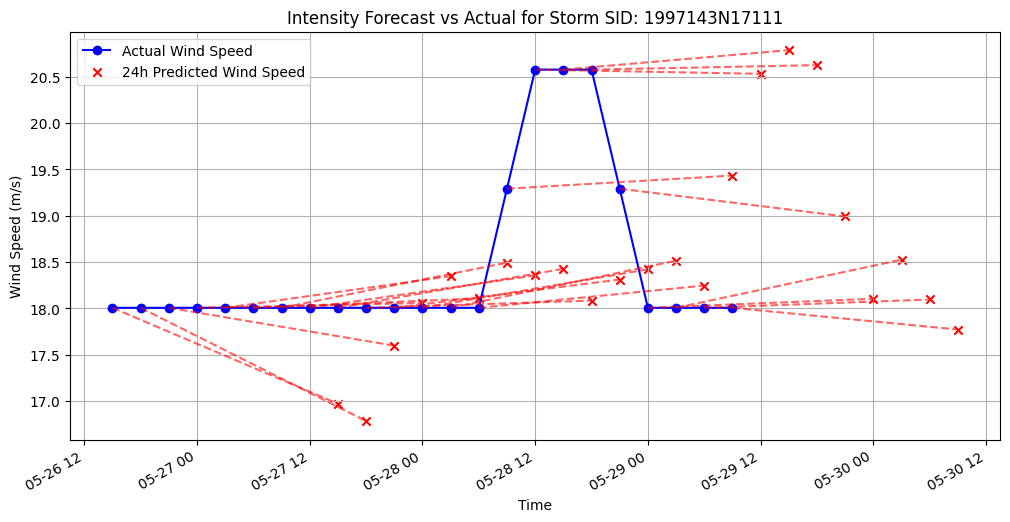

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


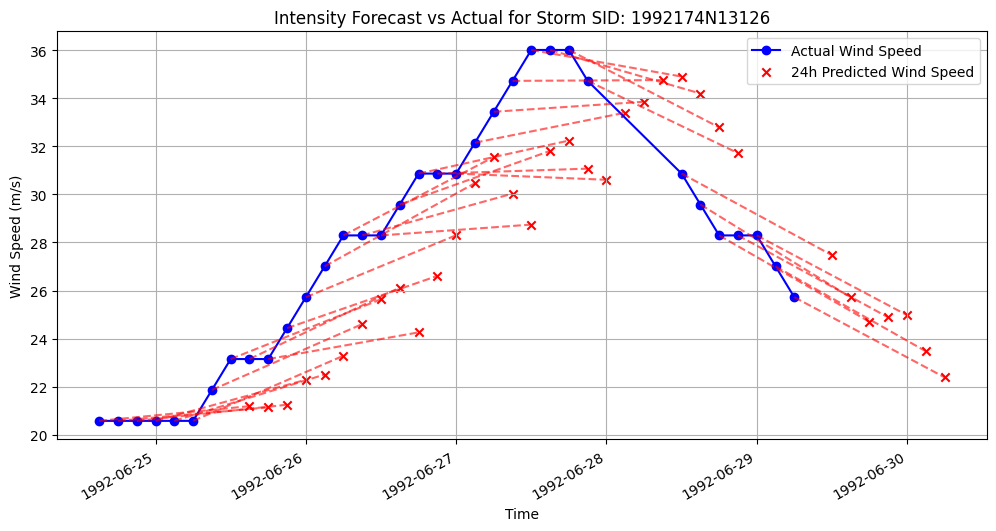


--- Residual Analysis for 24h Intensity Forecast ---


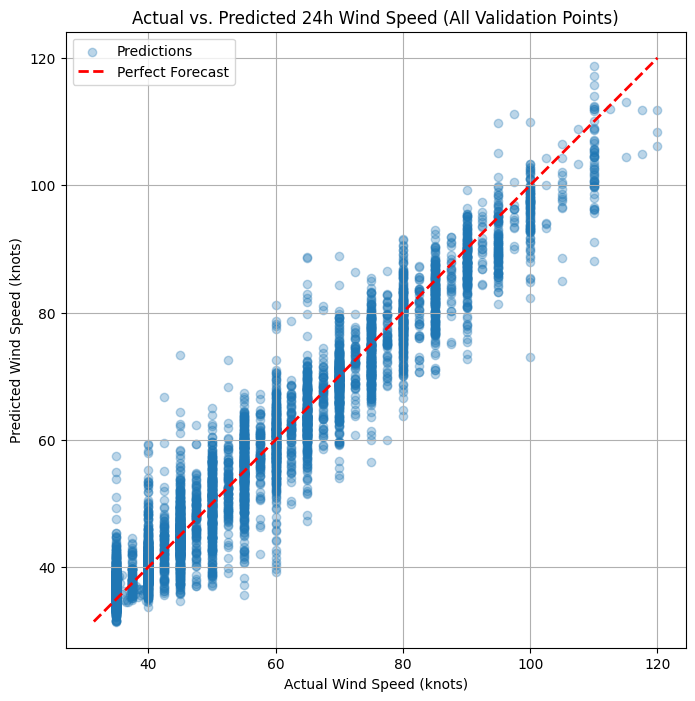


PHASE 5 COMPLETE. Evaluation finished.


In [ ]:
# ==============================================================================
# Phase 5: Comprehensive Model Evaluation (with Enhanced Visualizations)
# ==============================================================================
#
# --- TABLE OF CONTENTS ---
# 1. Setup and Data Loading
# 2. Re-creation of Features and Data Splits for Standalone Evaluation
# 3. Loading of Scalers and Trained Model
# 4. Making Predictions on the Validation Set
# 5. Performance Summary Tables (NEW)
# 6. Detailed Quantitative Evaluation (Original)
# 7. Detailed RI Evaluation (Original)
# 8. Visualization: Error vs. Lead Time (Original)
# 9. Visualization: Sample Storm Tracks (Original)
# 10. Visualization: Sample Intensity Profiles (NEW - As Requested)
# 11. Visualization: Residual Analysis for Intensity Forecasts (NEW - Extra)
#
# ==============================================================================

import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, classification_report, roc_curve, auc, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import pickle # Used for loading saved scaler objects

print("Starting Phase 5: Comprehensive Model Evaluation...")

# --- 1. SETUP AND DATA LOADING ---
# This section ensures the script can run independently by loading the necessary data.
try:
    df = pd.read_csv('/content/drive/MyDrive/Cyclone-TrackAI_Project/df_model_ready_partial.csv')
    # Ensure ISO_TIME is a datetime object for plotting
    df['ISO_TIME'] = pd.to_datetime(df['ISO_TIME'])
    print("Dataset 'df_model_ready_partial.csv' loaded successfully for evaluation.")
except FileNotFoundError:
    print("Error: 'df_model_ready_partial.csv' not found. Please make sure the file is available.")
    exit()

# --- 2. RE-CREATION OF FEATURES AND DATA SPLITS ---
# This mirrors the preprocessing from the training phase to ensure data consistency.

# Feature Engineering
for lag in [1, 2, 3]:
    df[f'LAT_delta_lag{lag}'] = df[f'LAT_lag{lag}'] - df[f'LAT_lag{lag+1}']
    df[f'LON_delta_lag{lag}'] = df[f'LON_lag{lag}'] - df[f'LON_lag{lag+1}']
df.dropna(inplace=True)

# Define feature and label columns
static_features = [
    'SEASON', 'LAT', 'LON', 'WMO_WIND', 'WMO_PRES', 'SST', 'RH_500', 'RH_850',
    'U_200', 'V_200', 'U_850', 'V_850', 'VWS', 'U_STORM', 'V_STORM'
]
temporal_features = []
num_temporal_features_per_step = 8
for lag in [1, 2, 3, 4]:
    for col in ['LAT', 'LON', 'WMO_WIND', 'WMO_PRES', 'U_STORM', 'V_STORM', 'LAT_delta', 'LON_delta']:
        feature_name = f'{col}_lag{lag}'
        if feature_name not in df.columns: df[feature_name] = 0
        temporal_features.append(feature_name)
lead_times = [6, 12, 24, 48, 72]
track_labels = [f'{col}_fwd{h}' for h in lead_times for col in ['LAT', 'LON']]
intensity_labels = [f'WMO_WIND_fwd{h}' for h in lead_times]
ri_label = ['RI_12h_label']
all_labels = track_labels + intensity_labels + ri_label

# Data Splitting (must be identical to training split)
unique_sids = df['SID'].unique()
np.random.seed(42) # Use a fixed seed for reproducibility
train_sids, val_sids = np.split(np.random.permutation(unique_sids), [int(0.8 * len(unique_sids))])
train_df = df[df['SID'].isin(train_sids)].copy()
val_df = df[df['SID'].isin(val_sids)].copy()
X_val_static, X_val_temporal, y_val = val_df[static_features], val_df[temporal_features], val_df[all_labels]

# --- 3. LOADING OF SCALERS AND TRAINED MODEL ---
# Best Practice: Load scalers that were fitted ONLY on the training data.
try:
    with open('static_scaler.pkl', 'rb') as f:
        static_scaler = pickle.load(f)
    with open('temporal_scaler.pkl', 'rb') as f:
        temporal_scaler = pickle.load(f)
    print("Pre-fitted scalers loaded from .pkl files.")
except FileNotFoundError:
    print("NOTE: Scaler .pkl files not found. Fitting new scalers on the TRAINING data for this evaluation.")
    static_scaler = StandardScaler().fit(train_df[static_features])
    temporal_scaler = StandardScaler().fit(train_df[temporal_features])

X_val_static_scaled = static_scaler.transform(X_val_static)
X_val_temporal_scaled = temporal_scaler.transform(X_val_temporal)
X_val_temporal_reshaped = X_val_temporal_scaled.reshape(len(X_val_temporal), 4, num_temporal_features_per_step)

from tensorflow.keras.losses import mse, binary_crossentropy
try:
    model = tf.keras.models.load_model(
        "typhoon_forecast_model_v2_attention.h5",
        custom_objects={'mse': mse, 'binary_crossentropy': binary_crossentropy}
    )
    print("Trained model 'typhoon_forecast_model_v2_attention.h5' loaded successfully.")
except Exception as e:
    print(f"FATAL ERROR: Could not load model. {e}")
    model = None

# --- 4. MAKING PREDICTIONS ---
if model is not None:
    print("\nMaking predictions on the validation data...")
    predictions = model.predict(
        {'static_input': X_val_static_scaled, 'temporal_input': X_val_temporal_reshaped}
    )
    track_preds, intensity_preds, ri_preds = predictions[0], predictions[1], predictions[2]

    # --- 5. PERFORMANCE SUMMARY TABLES (NEW) ---
    KNOTS_TO_MS = 0.514444
    DEG_LAT_TO_KM = 111.0

    print("\n\n========================= MODEL PERFORMANCE SUMMARY =========================")
    print("\nTable 1: Model and Data Configuration")
    print(f"--------------------------------------------------")
    print(f"  Validation Storms:    {len(val_sids)}")
    print(f"  Validation Data Points: {len(val_df)}")
    print(f"  Static Features:        {len(static_features)}")
    print(f"  Temporal Features:      {num_temporal_features_per_step} per timestep")
    print(f"  Forecast Horizons:      {lead_times} hours")
    print(f"--------------------------------------------------")

    print("\nTable 2: Track Forecast Error Summary (Mean Absolute Error)")
    print("-----------------------------------------------------------------------------")
    print("  Lead Time | Lat MAE (°) | Lon MAE (°) | Approx. Error (km Lat, km Lon)")
    print("-----------------------------------------------------------------------------")
    for i, h in enumerate(lead_times):
        lat_mae = mean_absolute_error(y_val[f'LAT_fwd{h}'], track_preds[:, i*2])
        lon_mae = mean_absolute_error(y_val[f'LON_fwd{h}'], track_preds[:, i*2 + 1])
        avg_lat_rad = np.radians(val_df['LAT'].mean())
        deg_lon_to_km = DEG_LAT_TO_KM * np.cos(avg_lat_rad)
        print(f"  {h:<9} | {lat_mae:<11.2f} | {lon_mae:<11.2f} | (~{lat_mae * DEG_LAT_TO_KM:.1f} km, ~{lon_mae * deg_lon_to_km:.1f} km)")
    print("-----------------------------------------------------------------------------")

    print("\nTable 3: Intensity Forecast Error Summary (Mean Absolute Error)")
    print("---------------------------------------------------")
    print("  Lead Time | Wind Speed MAE (m/s)")
    print("---------------------------------------------------")
    for i, h in enumerate(lead_times):
        wind_mae_knots = mean_absolute_error(y_val[f'WMO_WIND_fwd{h}'], intensity_preds[:, i])
        print(f"  {h:<9} | {wind_mae_knots * KNOTS_TO_MS:<.2f}")
    print("---------------------------------------------------")

    ri_pred_labels = (ri_preds > 0.5).astype(int)
    actual_ri_labels = y_val['RI_12h_label']
    roc_auc_summary = roc_auc_score(actual_ri_labels, ri_preds)
    report = classification_report(actual_ri_labels, ri_pred_labels, target_names=['No RI', 'RI Event'], output_dict=True)
    print("\nTable 4: Rapid Intensification (12h) Forecast Summary")
    print("---------------------------------------------------")
    print(f"  ROC AUC Score:          {roc_auc_summary:.3f}")
    print(f"  Precision (RI Event):   {report['RI Event']['precision']:.2f}")
    print(f"  Recall (RI Event):      {report['RI Event']['recall']:.2f}")
    print(f"  F1-Score (RI Event):    {report['RI Event']['f1-score']:.2f}")
    print("---------------------------------------------------")
    print("\n===========================================================================\n")

    # --- 6. DETAILED RI EVALUATION (Original) ---
    print("\n--- Detailed Rapid Intensification (RI) Evaluation ---")
    print("Classification Report:")
    print(classification_report(actual_ri_labels, ri_pred_labels, target_names=['No RI', 'RI Event']))
    cm = confusion_matrix(actual_ri_labels, ri_pred_labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted No RI', 'Predicted RI'], yticklabels=['Actual No RI', 'Actual RI'])
    plt.title('RI Confusion Matrix')
    plt.show()

    fpr, tpr, _ = roc_curve(actual_ri_labels, ri_preds)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.title('Receiver Operating Characteristic (ROC) Curve for RI')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

    # --- 7. VISUALIZE ERRORS VS. LEAD TIME (Original, with Haversine) ---
    def haversine(lat1, lon1, lat2, lon2):
        R = 6371
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        dlon, dlat = lon2 - lon1, lat2 - lat1
        a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
        c = 2 * np.arcsin(np.sqrt(a)); return R * c
    track_errors_km = [np.mean(haversine(y_val[f'LAT_fwd{h}'], y_val[f'LON_fwd{h}'], track_preds[:, i*2], track_preds[:, i*2 + 1])) for i, h in enumerate(lead_times)]
    intensity_errors_knots = [mean_absolute_error(y_val[f'WMO_WIND_fwd{h}'], intensity_preds[:, i]) for i, h in enumerate(lead_times)]

    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.set_xlabel('Forecast Lead Time (hours)')
    ax1.set_ylabel('Track Error (km)', color='tab:blue')
    ax1.bar(lead_times, track_errors_km, color='tab:blue', alpha=0.6, label='Track Error')
    ax2 = ax1.twinx()
    ax2.set_ylabel('Intensity Error (knots)', color='tab:red')
    ax2.plot(lead_times, intensity_errors_knots, color='tab:red', marker='o', linestyle='--', label='Intensity Error')
    plt.title('Average Forecast Error vs. Lead Time')
    plt.grid(True)
    plt.show()

    # --- 8. VISUALIZE SAMPLE STORM TRACKS (Original) ---
    print("\n--- Visualizing Sample Storm Tracks ---")
    sample_sids = np.random.choice(val_df['SID'].unique(), size=3, replace=False)
    for sid in sample_sids:
        storm_df = val_df[val_df['SID'] == sid].sort_values('ISO_TIME')
        storm_static_scaled = static_scaler.transform(storm_df[static_features])
        storm_temporal_scaled = temporal_scaler.transform(storm_df[temporal_features])
        storm_temporal_reshaped = storm_temporal_scaled.reshape(len(storm_df), 4, 8)
        storm_preds_track = model.predict({'static_input': storm_static_scaled, 'temporal_input': storm_temporal_reshaped})[0]
        pred_24h_lat, pred_24h_lon = storm_preds_track[:, 4], storm_preds_track[:, 5]

        plt.figure(figsize=(10, 8))
        plt.plot(storm_df['LON'], storm_df['LAT'], marker='o', linestyle='-', label='Actual Track', color='navy')
        plt.scatter(pred_24h_lon, pred_24h_lat, marker='x', label='Predicted 24h Position', color='red', alpha=0.7)
        for i in range(len(storm_df)):
            plt.plot([storm_df['LON'].iloc[i], pred_24h_lon[i]], [storm_df['LAT'].iloc[i], pred_24h_lat[i]], linestyle='--', color='gray', alpha=0.5)
        plt.title(f'Actual vs. Predicted 24h Track for Storm SID: {sid}')
        plt.xlabel('Longitude'); plt.ylabel('Latitude'); plt.legend(); plt.grid(True)
        plt.show()

    # --- 9. VISUALIZE SAMPLE INTENSITY PROFILES (NEW - As Requested) ---
    print("\n--- Visualizing Sample Intensity Profiles ---")
    for sid in sample_sids: # Use the same sample storms for consistency
        storm_df = val_df[val_df['SID'] == sid].sort_values('ISO_TIME').copy() # Make a copy to avoid SettingWithCopyWarning
        # <--- FIX: Convert ISO_TIME to datetime objects within the loop
        storm_df['ISO_TIME'] = pd.to_datetime(storm_df['ISO_TIME'])

        storm_static_scaled = static_scaler.transform(storm_df[static_features])
        storm_temporal_scaled = temporal_scaler.transform(storm_df[temporal_features])
        storm_temporal_reshaped = storm_temporal_scaled.reshape(len(storm_df), 4, 8)

        storm_preds_intensity = model.predict({'static_input': storm_static_scaled, 'temporal_input': storm_temporal_reshaped})[1]

        # Get actual and predicted data
        actual_time = storm_df['ISO_TIME']
        actual_wind_ms = storm_df['WMO_WIND'] * KNOTS_TO_MS
        pred_24h_wind_ms = storm_preds_intensity[:, 2] * KNOTS_TO_MS # WMO_WIND_fwd24 is the 3rd element (index 2)

        plt.figure(figsize=(12, 6))
        plt.plot(actual_time, actual_wind_ms, marker='o', linestyle='-', color='blue', label='Actual Wind Speed')

        # Plot each 24h forecast from its origin point
        for i in range(len(storm_df)):
            forecast_origin_time = actual_time.iloc[i]
            forecast_valid_time = forecast_origin_time + pd.Timedelta(hours=24)
            plt.plot([forecast_origin_time, forecast_valid_time],
                     [actual_wind_ms.iloc[i], pred_24h_wind_ms[i]],
                     linestyle='--', color='red', alpha=0.6)

        # Add a scatter plot for predicted points for clarity, though not in the original image
        plt.scatter(actual_time + pd.Timedelta(hours=24), pred_24h_wind_ms, marker='x', color='red', label='24h Predicted Wind Speed')

        plt.title(f'Intensity Forecast vs Actual for Storm SID: {sid}')
        plt.xlabel('Time'); plt.ylabel('Wind Speed (m/s)'); plt.legend(); plt.grid(True)
        plt.gcf().autofmt_xdate() # Format date labels nicely
        plt.show()

    # --- 10. VISUALIZATION: RESIDUAL ANALYSIS FOR INTENSITY FORECASTS (NEW - Extra) ---
    print("\n--- Residual Analysis for 24h Intensity Forecast ---")
    actual_24h_wind_knots = y_val['WMO_WIND_fwd24']
    pred_24h_wind_knots = intensity_preds[:, 2]

    plt.figure(figsize=(8, 8))
    plt.scatter(actual_24h_wind_knots, pred_24h_wind_knots, alpha=0.3, label='Predictions')
    # Add a perfect prediction line (y=x)
    min_val = min(actual_24h_wind_knots.min(), pred_24h_wind_knots.min())
    max_val = max(actual_24h_wind_knots.max(), pred_24h_wind_knots.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Forecast')

    plt.title('Actual vs. Predicted 24h Wind Speed (All Validation Points)')
    plt.xlabel('Actual Wind Speed (knots)')
    plt.ylabel('Predicted Wind Speed (knots)')
    plt.legend(); plt.grid(True); plt.axis('equal')
    plt.show()


    print("\nPHASE 5 COMPLETE. Evaluation finished.")
else:
    print("\nModel could not be loaded. Aborting evaluation.")